# Causal Forecasting

Demonstrates `CausalForecaster` — graph-informed time series forecasting using discovered causal structure.

**Key idea:** The discovered causal graph tells us which lagged variables are *true causes* of each target. We use only those as predictors, eliminating spurious correlations. Exogenous variables (no causal parents) are forecasted with auto-ETS (Exponential Smoothing with automatic trend/seasonality detection).

**Features demonstrated:**
1. Causal discovery → forecasting pipeline
2. Auto-ETS fallback for exogenous (parentless) variables
3. Multi-step ahead forecasting
4. Comparison: causal features vs all-lags baseline
5. Custom sklearn models (Ridge, Random Forest)
6. Feature importance from the causal model

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from causalts.synthetic_data.synthetic_datasets import ex2
from causalts.effects.forecast import CausalForecaster, get_causal_parents

## 1. Generate Data and Discover Graph

We use **ex2** (6-variable linear system, max_lag=3). X0 is the sole root node (autoregressive only), driving everything downstream.

In [2]:
result = ex2(seed=42, T=600)
df = result['df']
true_graph = result['ground_truth'][:6, :6, :]  # strip C node
var_names = df.columns.tolist()

# Train/test split
T_train = 500
df_train = df.iloc[:T_train].reset_index(drop=True)
df_test = df.iloc[T_train:].reset_index(drop=True)

print(f'Dataset: {len(var_names)} variables, T_train={T_train}, T_test={len(df_test)}')
print(f'True graph edges: {int(true_graph.sum())}')
print(f'Root node (exogenous): X0 — only has self-loop X0(t-1)->X0')

Dataset: 6 variables, T_train=500, T_test=100
True graph edges: 11
Root node (exogenous): X0 — only has self-loop X0(t-1)->X0


## 2. Causal Forecasting with True Graph

First, use the **true causal graph** to demonstrate the forecasting pipeline without discovery noise.

In [3]:
# Fit forecaster using true graph (include_contemp=False for multi-step)
forecaster = CausalForecaster(
    true_graph, var_names=var_names, include_contemp=False
)
forecaster.fit(df_train)
print(forecaster)
print(f'\nCausal models: {list(forecaster.models_.keys())}')
print(f'ETS models (exogenous): {list(forecaster.exog_models_.keys())}')

# Show parents used for each variable
print('\nSelected features per target:')
for var in var_names:
    if var in forecaster.parents_:
        parents = forecaster.parents_[var]
        print(f'  {var}: {["{0}(t-{1})".format(v, l) for v, l in parents]}')
    elif var in forecaster.exog_models_:
        print(f'  {var}: auto-ETS (exogenous)')

CausalForecaster(causal=6, exog_ets=0, model=LinearRegression)

Causal models: ['X0', 'X1', 'X2', 'X3', 'X4', 'X5']
ETS models (exogenous): []

Selected features per target:
  X0: ['X0(t-1)']
  X1: ['X0(t-2)']
  X2: ['X0(t-3)']
  X3: ['X0(t-2)', 'X3(t-1)', 'X4(t-1)']
  X4: ['X3(t-1)', 'X4(t-1)']
  X5: ['X2(t-1)', 'X4(t-2)', 'X5(t-1)']


In [4]:
# In-sample fit quality
scores = forecaster.score(df_train)
print('In-sample R² (training data):')
for var, r2 in sorted(scores.items()):
    model_type = 'ETS' if var in forecaster.exog_models_ else 'Causal'
    print(f'  {var}: R²={r2:.4f} ({model_type})')

In-sample R² (training data):
  X0: R²=0.5508 (Causal)
  X1: R²=0.3429 (Causal)
  X2: R²=0.2518 (Causal)
  X3: R²=0.6188 (Causal)
  X4: R²=0.6473 (Causal)
  X5: R²=0.6539 (Causal)


## 3. Auto AR/ETS for Exogenous Variables

When the discovery algorithm misses a self-loop (common!) or a variable is truly exogenous, the `exog_fallback` activates. Here we simulate this by removing X0's self-loop.

The fallback fits the **best model from AR(1–3) and ETS candidates, selected by AIC**. For a stationary AR process like X0 (no trend, no seasonality), AR(1) wins by AIC and iterates correctly over the full horizon. The old SES-only fallback would predict a flat line beyond step 1, which is why it was 3× worse than the explicit AR model.

CausalForecaster(causal=5, exog_ets=1, model=LinearRegression)

Causal models: ['X1', 'X2', 'X3', 'X4', 'X5']
ETS fallback:  ['X0']


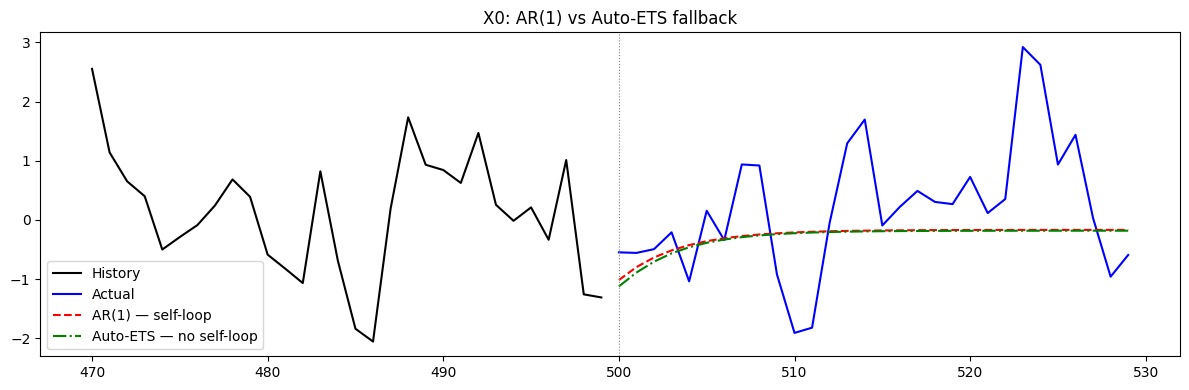

X0 forecast MSE — AR(1): 1.3248, ETS: 1.3445


In [5]:
# Remove X0's self-loop to simulate a discovery miss
graph_no_selfloop = true_graph.copy()
graph_no_selfloop[0, 0, :] = 0  # X0 now has zero parents

f_ets = CausalForecaster(graph_no_selfloop, var_names=var_names, include_contemp=False)
f_ets.fit(df_train)
print(f_ets)
print(f'\nCausal models: {list(f_ets.models_.keys())}')
print(f'ETS fallback:  {list(f_ets.exog_models_.keys())}')

# Compare X0 forecast: AR(1) via causal model vs ETS fallback
horizon = 30
fcast_ar = forecaster.forecast_horizon(df_train, horizon=horizon)
fcast_ets = f_ets.forecast_horizon(df_train, horizon=horizon)

fig, ax = plt.subplots(figsize=(12, 4))
t_hist = np.arange(T_train - 30, T_train)
t_fcast = np.arange(T_train, T_train + horizon)

ax.plot(t_hist, df_train['X0'].iloc[-30:].values, 'k-', lw=1.5, label='History')
ax.plot(t_fcast, df_test['X0'].values[:horizon], 'b-', lw=1.5, label='Actual')
ax.plot(t_fcast, fcast_ar['X0'].values, 'r--', lw=1.5, label='AR(1) — self-loop')
ax.plot(t_fcast, fcast_ets['X0'].values, 'g-.', lw=1.5, label='Auto-ETS — no self-loop')
ax.axvline(T_train, color='gray', ls=':', lw=0.8)
ax.set_title('X0: AR(1) vs Auto-ETS fallback')
ax.legend()
plt.tight_layout()
plt.show()

mse_ar = np.mean((df_test['X0'].values[:horizon] - fcast_ar['X0'].values) ** 2)
mse_ets = np.mean((df_test['X0'].values[:horizon] - fcast_ets['X0'].values) ** 2)
print(f'X0 forecast MSE — AR(1): {mse_ar:.4f}, ETS: {mse_ets:.4f}')

## 3.5. Exogenous Variables

Pass known future values of external regressors via `exog=` at fit time and `exog_future=` at forecast time. Exogenous columns are added as **lag-0 (contemporaneous) features** to every causal regression model.

**When to use:** weather, calendar features, policy indicators, or any covariate whose future values are known at forecast time but is not part of the causal graph.

When `exog` is provided the AR/ETS fallback is suppressed — all variables (including parentless ones) receive a regression model with the exog features.

CausalForecaster(causal=6, exog_ets=0, model=LinearRegression, exog_features=1)

One-step X3 MSE — no exog: 3.0249, with exog Z: 2.0583  (+32.0%)
30-step X3 MSE  — no exog: 2.4058, with exog Z: 1.5641  (+35.0%)


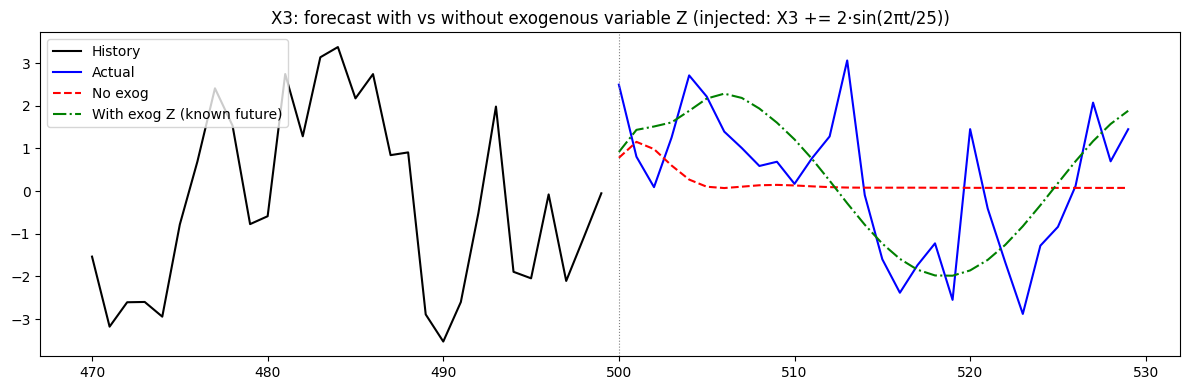


Feature importance for X3 (causal parents + exog Z):
parent  lag  importance
exog_Z    0    1.404386
    X4    1    0.627293
    X0    2    0.561073
    X3    1    0.278504


In [6]:
np.random.seed(7)
T_total = T_train + len(df_test)

# Synthetic exog: a periodic driver injected into X3 with a strong enough
# effect to demonstrate the improvement clearly (coef=2.0)
Z_all = np.sin(2 * np.pi * np.arange(T_total) / 25)
exog_all = pd.DataFrame({'Z': Z_all})

df_all = df.copy()
df_all['X3'] = df_all['X3'] + 2.0 * Z_all  # X3 now depends on Z

df_train_z = df_all.iloc[:T_train].reset_index(drop=True)
df_test_z  = df_all.iloc[T_train:].reset_index(drop=True)
exog_train  = exog_all.iloc[:T_train].reset_index(drop=True)
exog_test   = exog_all.iloc[T_train:].reset_index(drop=True)

horizon = 30
exog_future = exog_test.iloc[:horizon].reset_index(drop=True)

# Without exog (Z is a hidden driver)
f_no_z = CausalForecaster(true_graph, var_names=var_names, include_contemp=False)
f_no_z.fit(df_train_z)

# With exog (Z is provided as a known external input)
f_with_z = CausalForecaster(true_graph, var_names=var_names, include_contemp=False)
f_with_z.fit(df_train_z, exog=exog_train)
print(f_with_z)

# --- One-step-ahead comparison ---
preds_no_z   = f_no_z.predict(df_test_z)
preds_with_z = f_with_z.predict(df_test_z, exog=exog_test)
max_lag = 3
actual_x3 = df_test_z['X3'].values[max_lag:]
mse_no_1  = np.mean((actual_x3 - preds_no_z['X3'].dropna().values[:len(actual_x3)])**2)
mse_wi_1  = np.mean((actual_x3 - preds_with_z['X3'].dropna().values[:len(actual_x3)])**2)
print(f'\nOne-step X3 MSE — no exog: {mse_no_1:.4f}, with exog Z: {mse_wi_1:.4f}  '
      f'({(mse_no_1-mse_wi_1)/mse_no_1*100:+.1f}%)')

# --- Multi-step forecast comparison ---
fcast_no_z   = f_no_z.forecast_horizon(df_train_z, horizon=horizon)
fcast_with_z = f_with_z.forecast_horizon(df_train_z, horizon=horizon, exog_future=exog_future)

actual_x3_h = df_test_z['X3'].values[:horizon]
mse_no_h    = np.mean((actual_x3_h - fcast_no_z['X3'].values)**2)
mse_wi_h    = np.mean((actual_x3_h - fcast_with_z['X3'].values)**2)
print(f'{horizon}-step X3 MSE  — no exog: {mse_no_h:.4f}, with exog Z: {mse_wi_h:.4f}  '
      f'({(mse_no_h-mse_wi_h)/mse_no_h*100:+.1f}%)')

fig, ax = plt.subplots(figsize=(12, 4))
t_h = np.arange(T_train - 30, T_train)
t_f = np.arange(T_train, T_train + horizon)
ax.plot(t_h, df_train_z['X3'].iloc[-30:].values, 'k-', lw=1.5, label='History')
ax.plot(t_f, actual_x3_h, 'b-', lw=1.5, label='Actual')
ax.plot(t_f, fcast_no_z['X3'].values, 'r--', lw=1.5, label='No exog')
ax.plot(t_f, fcast_with_z['X3'].values, 'g-.', lw=1.5, label='With exog Z (known future)')
ax.axvline(T_train, color='gray', ls=':', lw=0.8)
ax.set_title('X3: forecast with vs without exogenous variable Z (injected: X3 += 2·sin(2πt/25))')
ax.legend()
plt.tight_layout()
plt.show()

print('\nFeature importance for X3 (causal parents + exog Z):')
print(f_with_z.feature_importance('X3').to_string(index=False))

## 4. Multi-Step Ahead Forecasting

Forecast 100 steps with the full true graph. All variables use causal models; X0 uses its own lag-1 (autoregressive).

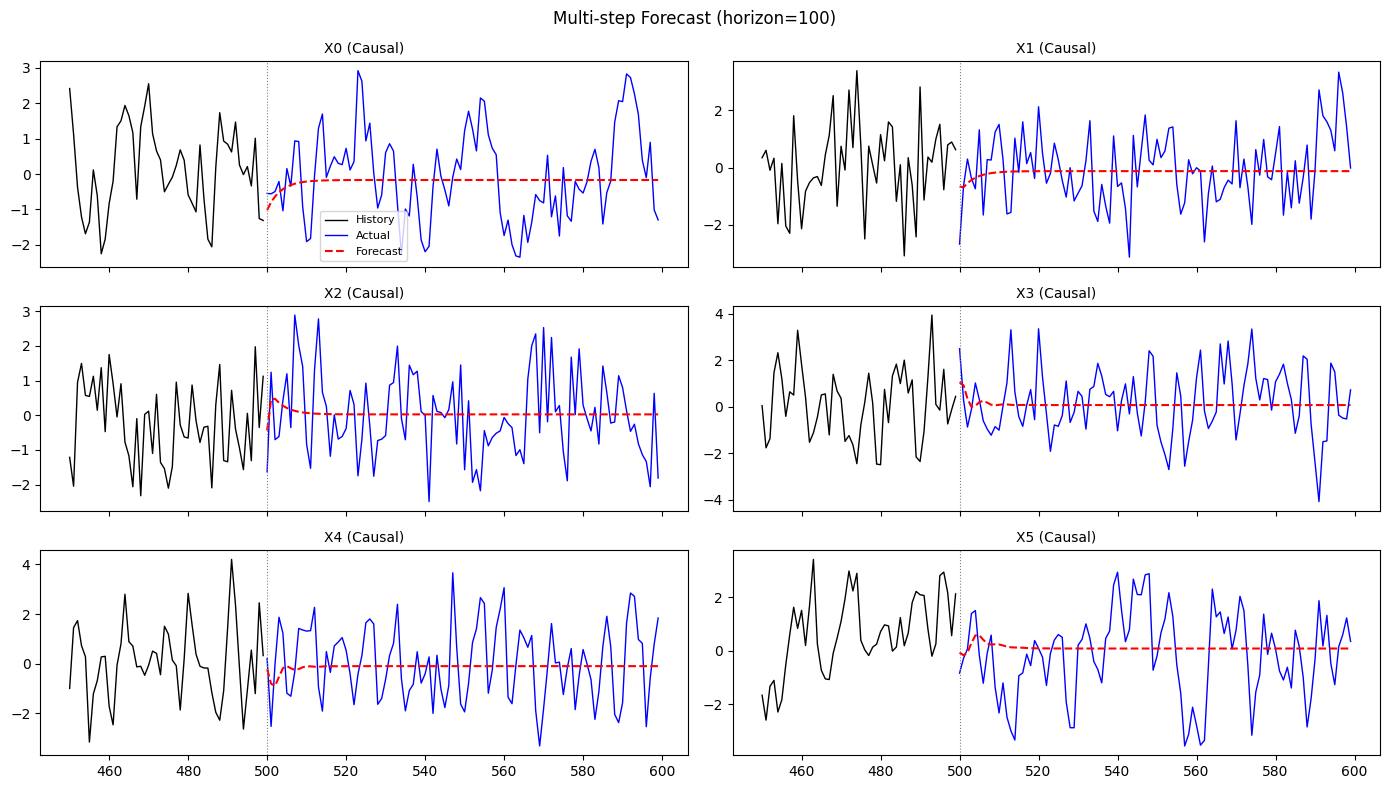

Forecast MSE (out-of-sample):
  X0: MSE=1.5949, normalized=1.0103
  X1: MSE=1.4638, normalized=0.9907
  X2: MSE=1.3639, normalized=0.9846
  X3: MSE=1.9399, normalized=0.9982
  X4: MSE=2.2111, normalized=1.0137
  X5: MSE=2.5693, normalized=1.0311


In [7]:
horizon = len(df_test)
fcast = forecaster.forecast_horizon(df_train, horizon=horizon)

fig, axes = plt.subplots(3, 2, figsize=(14, 8), sharex=True)
for idx, var in enumerate(var_names):
    ax = axes[idx // 2, idx % 2]
    t_hist = np.arange(T_train - 50, T_train)
    t_fcast = np.arange(T_train, T_train + horizon)

    ax.plot(t_hist, df_train[var].iloc[-50:].values, 'k-', lw=1, label='History')
    ax.plot(t_fcast, df_test[var].values, 'b-', lw=1, label='Actual')
    ax.plot(t_fcast, fcast[var].values, 'r--', lw=1.5, label='Forecast')
    ax.axvline(T_train, color='gray', ls=':', lw=0.8)

    model_type = 'ETS' if var in forecaster.exog_models_ else 'Causal'
    ax.set_title(f'{var} ({model_type})', fontsize=10)
    if idx == 0:
        ax.legend(fontsize=8)

plt.suptitle(f'Multi-step Forecast (horizon={horizon})', fontsize=12)
plt.tight_layout()
plt.show()

print('Forecast MSE (out-of-sample):')
for var in var_names:
    mse = np.mean((df_test[var].values - fcast[var].values) ** 2)
    var_total = np.var(df_test[var].values)
    print(f'  {var}: MSE={mse:.4f}, normalized={mse/var_total:.4f}')

## 5. Comparison: Causal vs All-Lags Baseline

Compare the causal forecaster (only true parents as features) against a baseline that uses **all variables at all lags** — i.e., a standard VAR-style approach without causal feature selection.

> **Note:** The causal model is not expected to win on raw prediction error here. The comparison is included to illustrate the tradeoff — see the interpretation cell below.

In [8]:
from sklearn.linear_model import Ridge

# Dense graph = all variables at all lags (VAR-style baseline)
max_lag = true_graph.shape[2] - 1
dense_graph = np.ones((6, 6, max_lag + 1), dtype=int)
# Remove contemporaneous self-loops
for i in range(6):
    dense_graph[i, i, 0] = 0

# Use Ridge to handle the larger feature set
baseline = CausalForecaster(
    dense_graph, var_names=var_names, model=Ridge(alpha=1.0),
    include_contemp=False, exog_fallback=False
)
baseline.fit(df_train)

# Causal forecaster with Ridge too (for fair comparison)
causal = CausalForecaster(
    true_graph, var_names=var_names, model=Ridge(alpha=1.0),
    include_contemp=False
)
causal.fit(df_train)

# One-step-ahead out-of-sample evaluation
causal_preds = causal.predict(df_test)
baseline_preds = baseline.predict(df_test)

print(f'{"Variable":<8} {"Causal MSE":>12} {"Baseline MSE":>14} {"Improvement":>12}')
print('-' * 50)
for var in var_names:
    if var not in baseline_preds.columns:
        continue
    actual = df_test[var].values[max_lag:]
    c_pred = causal_preds[var].dropna().values[:len(actual)]
    b_pred = baseline_preds[var].dropna().values[:len(actual)]
    n = min(len(actual), len(c_pred), len(b_pred))
    mse_c = np.mean((actual[:n] - c_pred[:n]) ** 2)
    mse_b = np.mean((actual[:n] - b_pred[:n]) ** 2)
    improvement = (mse_b - mse_c) / mse_b * 100
    print(f'{var:<8} {mse_c:>12.4f} {mse_b:>14.4f} {improvement:>+11.1f}%')

Variable   Causal MSE   Baseline MSE  Improvement
--------------------------------------------------
X0             1.7717         0.8439      -109.9%
X1             1.3424         1.0764       -24.7%
X2             1.1221         1.1374        +1.3%
X3             1.7326         0.7952      -117.9%
X4             3.7262         1.0279      -262.5%
X5             1.9931         0.7654      -160.4%



**Why use a causal model then?**

| Property | Causal model | Dense baseline |
|----------|-------------|----------------|
| Stable under intervention | Yes | No — correlations break when you externally force a variable |
| Interpretable coefficients | Yes | No — mixes direct and indirect effects |
| Generalizes across distribution shifts / regime changes | Yes | No |

The dense baseline is exploiting *spurious-but-stable* correlations that hold in the training distribution. If the distribution shifts — a new regime, an external intervention, a policy change — those correlations break and the causal model is the one that stays valid.

## 6. Custom Models

Any sklearn-compatible regressor works. Here we compare Linear, Ridge, and Random Forest.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42),
}

results = {}
for name, model in models.items():
    f = CausalForecaster(true_graph, var_names=var_names, model=model, include_contemp=False)
    f.fit(df_train)
    preds = f.predict(df_test)
    mses = {}
    for var in var_names:
        if var in preds.columns and var in f.models_:
            actual = df_test[var].values[max_lag:]
            pred = preds[var].dropna().values[:len(actual)]
            n = min(len(actual), len(pred))
            mses[var] = np.mean((actual[:n] - pred[:n]) ** 2)
    results[name] = mses

print(f'{"Variable":<8}', end='')
for name in models:
    print(f'{name:>14}', end='')
print()
print('-' * (8 + 14 * len(models)))
for var in var_names:
    if var not in results['Linear']:
        continue
    print(f'{var:<8}', end='')
    for name in models:
        print(f'{results[name][var]:>14.4f}', end='')
    print()

Variable        Linear         Ridge  RandomForest
--------------------------------------------------
X0              1.7726        1.7717        1.9436
X1              1.3427        1.3424        1.4184
X2              1.1221        1.1221        1.2087
X3              1.7335        1.7326        1.5914
X4              3.7280        3.7262        3.5720
X5              1.9939        1.9931        2.0560


## 7. Feature Importance

For linear models, the coefficients show each parent's direct contribution to the forecast.

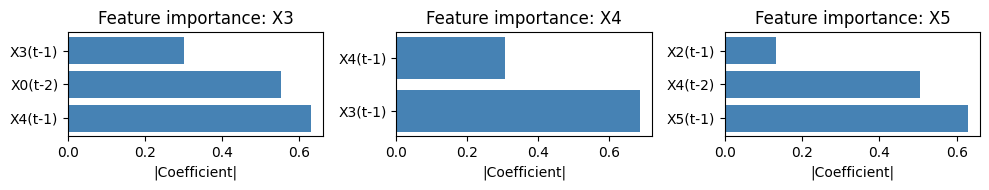

In [10]:
f_linear = CausalForecaster(true_graph, var_names=var_names, include_contemp=False)
f_linear.fit(df_train)

fig, axes = plt.subplots(1, 3, figsize=(10, 2))
for ax, var in zip(axes, ['X3', 'X4', 'X5']):
    imp = f_linear.feature_importance(var)
    labels = [f"{row['parent']}(t-{row['lag']})" for _, row in imp.iterrows()]
    ax.barh(labels, imp['importance'], color='steelblue')
    ax.set_xlabel('|Coefficient|')
    ax.set_title(f'Feature importance: {var}')

plt.tight_layout()
plt.show()

## 8. End-to-End: Discovery to Forecast

Full pipeline: discover the graph with CDNOTS, then forecast.

In [12]:
from causalts import run_cdnots
from causalts.ci_tests import PartialCorr
from causalts.effects import wrap_graph
from causalts.utils import evaluate_graph

# Discover
ci = PartialCorr(data=np.zeros((2, 2)))
_res = run_cdnots(
    df_train, ci, num_lags=3, include_C=False, alpha=0.05, stable=True
)

m = evaluate_graph(_res.cg_tig, true_graph)
print(f'Discovery: F1={m["F1"]:.2f}, Precision={m["Precision"]:.2f}, Recall={m["TPR"]:.2f}')

# Forecast using discovered graph
cg_wrapped = wrap_graph(_res.cg_tig, df_train)
fc = cg_wrapped.forecast(include_contemp=False)
print(f'\n{fc}')

fcast_disc = fc.forecast_horizon(df_train, horizon=len(df_test))

print(f'\nForecast MSE (discovered graph vs true graph):')
print(f'{"Variable":<8} {"Discovered":>12} {"True graph":>12}')
print('-' * 34)

fcast_true = forecaster.forecast_horizon(df_train, horizon=len(df_test))
for var in var_names:
    actual = df_test[var].values
    mse_d = np.mean((actual - fcast_disc[var].values) ** 2)
    mse_t = np.mean((actual - fcast_true[var].values) ** 2)
    print(f'{var:<8} {mse_d:>12.4f} {mse_t:>12.4f}')

Discovery: F1=0.76, Precision=0.80, Recall=0.73

CausalForecaster(causal=6, exog_ets=0, model=LinearRegression)

Forecast MSE (discovered graph vs true graph):
Variable   Discovered   True graph
----------------------------------
X0             1.5949       1.5949
X1             1.4638       1.4638
X2             1.3668       1.3639
X3             1.9292       1.9399
X4             2.1862       2.2111
X5             2.5583       2.5693


## Summary

| Feature | API |
|---------|-----|
| Fit forecaster | `CausalForecaster(graph, var_names).fit(df)` |
| Fit with exogenous | `forecaster.fit(df, exog=exog_df)` |
| In-sample predictions | `forecaster.predict(df, exog=exog_df)` |
| R² scores | `forecaster.score(df, exog=exog_df)` |
| Multi-step forecast | `forecaster.forecast_horizon(df, horizon=N, exog_future=exog_N)` |
| Feature importance | `forecaster.feature_importance(target)` |
| Via WrappedGraph | `cg.forecast(include_contemp=False)` |

**Key design:**
- Causal parents → sklearn model (any regressor)
- Exogenous variables → lag-0 features added to all causal models; future values required at forecast time
- Parentless variables → auto-selected AR(1–3) or ETS fallback (by AIC); AR wins for stationary series, ETS wins for trending/seasonal ones
- Multi-step iterates: ETS/AR forecasts exogenous → causal model uses those as inputs